<a href="https://colab.research.google.com/github/triveni898/QuantumSkin-Hybrid/blob/main/QuantumSkin_Hybrid_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# QuantumSkin — Colab notebook
This notebook trains the hybrid classical–quantum skin lesion classifier (ResNet18 → angle encoding → small VQC → classifier) in Google Colab.

**Two ways to provide dataset:**

1. Use Kaggle API (recommended for HAM10000). You must upload `kaggle.json` for authentication.
2. Upload a ZIP file via the Colab file upload UI (or mount Google Drive).

Follow the steps in the next cells.

In [ ]:
# Install required packages (run this cell in Colab)
!pip install -q torch torchvision
!pip install -q pennylane
!pip install -q scikit-learn tqdm Pillow
print('Installed core packages.\nTorch version:', __import__('torch').__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.3/934.3 kB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 55.0 MB/s eta 0:00:00
Installed core packages.
Torch version: 2.9.0+cu126


## Option A — Download HAM10000 via Kaggle
Upload `kaggle.json` using the Colab file upload UI, then run the Kaggle download command (example provided in the notebook).

In [ ]:
# Upload kaggle.json (if you want to use Kaggle). Run only if you have kaggle.json.
from google.colab import files
import os
if not os.path.exists('/root/.kaggle/kaggle.json'):
    print('Please upload your kaggle.json now (this opens a file picker).')
    uploaded = files.upload()
    for fn in uploaded:
        os.makedirs('/root/.kaggle', exist_ok=True)
        with open('/root/.kaggle/kaggle.json','wb') as f:
            f.write(uploaded[fn])
    os.chmod('/root/.kaggle/kaggle.json', 0o600)
    print('Uploaded kaggle.json')
else:
    print('kaggle.json already exists.')

Please upload your kaggle.json now (this opens a file picker).


Saving kaggle.json to kaggle.json
Uploaded kaggle.json


## Option B — Upload dataset ZIP directly
Upload a ZIP of your dataset; the notebook will extract and try to prepare `data/train` and `data/val`.

In [ ]:
# Upload dataset ZIP (runs a file picker)
from google.colab import files
import zipfile, os
print('Upload your dataset ZIP now (or skip if using Kaggle).')
uploaded = files.upload()
dataset_zip = None
for fn in uploaded:
    if fn.lower().endswith('.zip'):
        dataset_zip = fn
        break
if dataset_zip:
    print('Uploaded', dataset_zip)
    extract_dir = '/content/dataset'
    os.makedirs(extract_dir, exist_ok=True)
    with zipfile.ZipFile(dataset_zip, 'r') as z:
        z.extractall(extract_dir)
    print('Extracted to', extract_dir)
else:
    print('No ZIP uploaded. If you plan to use Kaggle, download the dataset using Kaggle API cell.')

## Prepare dataset (auto-split if needed)
This cell will try to detect class folders and create `/content/data/train` and `/content/data/val`.

In [ ]:
# Data preparation helper
import os, shutil, random
from pathlib import Path
def prepare_dataset_from_extracted(root, target='/content/data', split=0.8, seed=42):
    random.seed(seed)
    target = Path(target)
    if target.exists():
        shutil.rmtree(target)
    (target/'train').mkdir(parents=True)
    (target/'val').mkdir(parents=True)
    # detect train/val
    if (Path(root)/'train').exists() and (Path(root)/'val').exists():
        shutil.copytree(str(Path(root)/'train'), str(target/'train'), dirs_exist_ok=True)
        shutil.copytree(str(Path(root)/'val'), str(target/'val'), dirs_exist_ok=True)
        return str(target)
    class_folders = [p for p in Path(root).iterdir() if p.is_dir()]
    if len(class_folders) > 0:
        for cls in class_folders:
            imgs = list(cls.glob('*'))
            imgs = [p for p in imgs if p.suffix.lower() in ['.jpg','.jpeg','.png']]
            if len(imgs)==0:
                continue
            random.shuffle(imgs)
            cut = int(len(imgs)*split)
            train_imgs = imgs[:cut]
            val_imgs = imgs[cut:]
            (target/'train'/cls.name).mkdir(parents=True, exist_ok=True)
            (target/'val'/cls.name).mkdir(parents=True, exist_ok=True)
            for p in train_imgs:
                shutil.copy(p, target/'train'/cls.name)
            for p in val_imgs:
                shutil.copy(p, target/'val'/cls.name)
        return str(target)
    return None

if os.path.exists('/content/dataset'):
    out = prepare_dataset_from_extracted('/content/dataset', target='/content/data')
    print('Result:', out)
else:
    print('No extracted dataset found. Skip or use Kaggle.')

No extracted dataset found. Skip or use Kaggle.


## Training cell
The cell below contains the full model and training loop. Adjust NUM_EPOCHS and BATCH_SIZE if needed. Run this after dataset is prepared.

In [ ]:
import os, shutil

os.makedirs('/root/.kaggle', exist_ok=True)
shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

print("kaggle.json is ready!")


kaggle.json is ready!


In [ ]:
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -p /content


Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.19G/5.20G [01:44<00:00, 98.7MB/s]
100% 5.20G/5.20G [01:44<00:00, 53.5MB/s]


In [ ]:
!unzip -q /content/skin-cancer-mnist-ham10000.zip -d /content/ham10000


In [ ]:
# Run this cell to remove old extraction and unzip fresh
import os
# remove old folder if it exists (safe)
if os.path.exists('/content/ham10000'):
    !rm -rf /content/ham10000
# unzip the kaggle-downloaded file (adjust zip filename if different)
!unzip -q /content/skin-cancer-mnist-ham10000.zip -d /content/ham10000

# quick listing to confirm extraction
print("Listing /content/ham10000 (top-level):")
!ls -la /content/ham10000 || true


Listing /content/ham10000 (top-level):
total 130820
drwxr-xr-x 6 root root     4096 Dec  8 04:16 .
drwxr-xr-x 1 root root     4096 Dec  8 04:15 ..
drwxr-xr-x 2 root root   172032 Dec  8 04:15 ham10000_images_part_1
drwxr-xr-x 2 root root   172032 Dec  8 04:15 HAM10000_images_part_1
drwxr-xr-x 2 root root   167936 Dec  8 04:16 ham10000_images_part_2
drwxr-xr-x 2 root root   167936 Dec  8 04:15 HAM10000_images_part_2
-rw-r--r-- 1 root root   563277 Oct  6  2019 HAM10000_metadata.csv
-rw-r--r-- 1 root root 30807979 Oct  6  2019 hmnist_28_28_L.csv
-rw-r--r-- 1 root root 91820383 Oct  6  2019 hmnist_28_28_RGB.csv
-rw-r--r-- 1 root root  2537778 Oct  6  2019 hmnist_8_8_L.csv
-rw-r--r-- 1 root root  7524968 Oct  6  2019 hmnist_8_8_RGB.csv


In [ ]:
# Paste and run this cell next — it defines the prepare_ham10000 function and runs it.
import os, shutil, random
from pathlib import Path
import pandas as pd

def prepare_ham10000(extracted_root='/content/ham10000', target='/content/data', split=0.8, seed=42):
    """
    Builds /content/data/train and /content/data/val from HAM10000 extracted folder.
    It searches for HAM10000_metadata.csv and an images folder, then copies images into class folders.
    """
    random.seed(seed)
    extracted_root = Path(extracted_root)
    if not extracted_root.exists():
        raise FileNotFoundError(f"Extracted root not found: {extracted_root}")
    # try to locate metadata CSV
    meta_csv = None
    # common names
    for p in extracted_root.rglob('HAM10000_metadata.csv'):
        meta_csv = p
        break
    # try common fallback names
    if meta_csv is None:
        for p in extracted_root.rglob('*metadata*.csv'):
            meta_csv = p
            break
    # locate images folder
    image_dir = None
    # common locations
    for p in extracted_root.rglob('*images*'):
        if p.is_dir():
            image_dir = p
            break
    # fallback: look for many jpg files in a folder
    if image_dir is None:
        for p in extracted_root.iterdir():
            if p.is_dir():
                jpgs = list(p.glob('*.jpg'))
                if len(jpgs) > 0:
                    image_dir = p
                    break

    if meta_csv is None or image_dir is None:
        print("Could not find metadata CSV or image folder automatically.")
        print("Found files/directories in extracted_root (top 20):")
        for p in list(extracted_root.iterdir())[:20]:
            print(" ", p.name)
        return None

    print("Found metadata:", meta_csv)
    print("Found image folder:", image_dir)

    df = pd.read_csv(meta_csv)
    # Expect columns: image_id, dx (diagnosis)
    if 'image_id' not in df.columns or 'dx' not in df.columns:
        print("Metadata CSV doesn't have expected columns. Columns found:", df.columns.tolist())
        return None

    # create target structure
    target = Path(target)
    if target.exists():
        shutil.rmtree(target)
    (target/'train').mkdir(parents=True, exist_ok=True)
    (target/'val').mkdir(parents=True, exist_ok=True)

    # group by diagnosis and copy files
    for cls, g in df.groupby('dx'):
        files = []
        for _, row in g.iterrows():
            img_name = str(row['image_id']) + '.jpg'
            img_path = image_dir / img_name
            # handle jpg vs jpeg if needed
            if not img_path.exists():
                img_path = image_dir / (str(row['image_id']) + '.jpeg')
            if img_path.exists():
                files.append(img_path)
        if len(files) == 0:
            # skip empty classes
            continue
        random.shuffle(files)
        cut = int(len(files) * split)
        train_files = files[:cut]
        val_files = files[cut:]
        (target/'train'/cls).mkdir(parents=True, exist_ok=True)
        (target/'val'/cls).mkdir(parents=True, exist_ok=True)
        for p in train_files:
            shutil.copy(p, target/'train'/cls/p.name)
        for p in val_files:
            shutil.copy(p, target/'val'/cls/p.name)
        print(f"Class {cls}: train={len(train_files)} val={len(val_files)}")
    print("Prepared dataset at", target)
    return str(target)

# Run the prepare function now
out = prepare_ham10000('/content/ham10000', target='/content/data')
print('Result:', out)
# show a quick check
if out:
    print("Train subfolders:", sorted([p.name for p in (Path(out)/'train').iterdir() if p.is_dir()]))
    print("Sample files in first class:", list((Path(out)/'train').glob('*/*'))[:5])


Found metadata: /content/ham10000/HAM10000_metadata.csv
Found image folder: /content/ham10000/ham10000_images_part_1
Class akiec: train=146 val=37
Class bcc: train=212 val=54
Class bkl: train=451 val=113
Class df: train=44 val=12
Class mel: train=348 val=87
Class nv: train=2744 val=687
Class vasc: train=52 val=13
Prepared dataset at /content/data
Result: /content/data
Train subfolders: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Sample files in first class: [PosixPath('/content/data/train/df/ISIC_0025314.jpg'), PosixPath('/content/data/train/df/ISIC_0024396.jpg'), PosixPath('/content/data/train/df/ISIC_0024973.jpg'), PosixPath('/content/data/train/df/ISIC_0027107.jpg'), PosixPath('/content/data/train/df/ISIC_0028790.jpg')]


In [ ]:
out = prepare_ham10000('/content/ham10000', target='/content/data')
print(out)


Found metadata: /content/ham10000/HAM10000_metadata.csv
Found image folder: /content/ham10000/ham10000_images_part_1
Class akiec: train=146 val=37
Class bcc: train=212 val=54
Class bkl: train=451 val=113
Class df: train=44 val=12
Class mel: train=348 val=87
Class nv: train=2744 val=687
Class vasc: train=52 val=13
Prepared dataset at /content/data
/content/data


## Save model to Google Drive
Mount drive and copy the saved `.pth` file to your Drive so you can download later.

Device: cuda
Using PennyLane: 0.43.1
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Train size: 3997 Val size: 1003
Class counts: {'akiec': np.float64(146.0), 'bcc': np.float64(212.0), 'bkl': np.float64(451.0), 'df': np.float64(44.0), 'mel': np.float64(348.0), 'nv': np.float64(2744.0), 'vasc': np.float64(52.0)}
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 66.4MB/s]


Starting training...


Epoch 1/25 | Train Loss: 1.9488 | Train Acc: 0.1424 | Val Acc: 0.0867 | Val F1: 0.0138 | Time: 436.3s
Saved best model (val_acc=0.0867) -> /content/best_quantum_skin.pth


Epoch 2/25 | Train Loss: 1.9336 | Train Acc: 0.1756 | Val Acc: 0.1635 | Val F1: 0.1531 | Time: 436.9s
Saved best model (val_acc=0.1635) -> /content/best_quantum_skin.pth


...

Epoch 21/25 | Train Loss: 0.5341 | Train Acc: 0.7711 | Val Acc: 0.7846 | Val F1: 0.7970 | Time: 462.4s
Saved best model (val_acc=0.7846) -> /content/best_quantum_skin.pth


Epoch 22/25 | Train Loss: 0.4998 | Train Acc: 0.7826 | Val Acc: 0.7727 | Val F1: 0.7880 | Time: 463.8s


Epoch 23/25 | Train Loss: 0.4821 | Train Acc: 0.7878 | Val Acc: 0.7647 | Val F1: 0.7844 | Time: 459.8s


Epoch 24/25 | Train Loss: 0.4758 | Train Acc: 0.7948 | Val Acc: 0.7827 | Val F1: 0.7983 | Time: 465.6s


Epoch 25/25 | Train Loss: 0.4602 | Train Acc: 0.8006 | Val Acc: 0.7916 | Val F1: 0.8023 | Time: 463.0s
Saved best model (val_acc=0.7916) -> /content/best_quantum_skin.pth
Training finished. Best val acc: 0.7916251246261217
Fitting temperature on validation set (grid-search fallback)...
Estimated temperature T = 1.2000000000000002


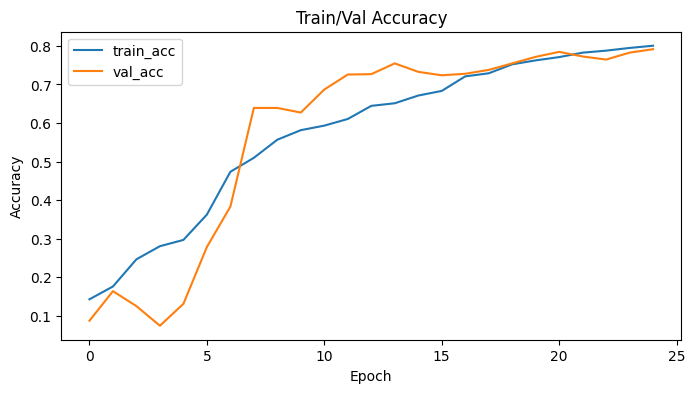

In [ ]:
# ---------------------------
# QuantumSkin - Improved Full Training + Inference (Colab-ready)
# Final recommended settings applied:
# NUM_EPOCHS = 25, LR = 5e-5, BATCH_SIZE = 32, VQC_QUBITS = 6, VQC_LAYERS = 4
# ---------------------------

# 0) If you haven't installed dependencies in this session, uncomment and run:
# !pip install -q pennylane
# !pip install -q torch torchvision scikit-learn tqdm Pillow

import os, math, time, random, copy
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision.datasets import ImageFolder
import pennylane as qml
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, log_loss
import matplotlib.pyplot as plt
from PIL import Image

# ---------------------------
# Config (final recommended settings)
# ---------------------------
NUM_EPOCHS = 25
LR = 5e-5
BATCH_SIZE = 32
VQC_QUBITS = 6
VQC_LAYERS = 4
IMAGE_SIZE = 224
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL_SAVE_PATH = '/content/best_quantum_skin.pth'
PRINT_EVERY_N = 1  # show epoch logs every epoch
SEED = 42

torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

print("Device:", DEVICE)
print("Using PennyLane:", qml.__version__)

# ---------------------------
# Data transforms & loaders
# ---------------------------
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.2),
    transforms.RandomRotation(25),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

DATA_DIR = '/content/data'   # must contain train/ and val/
train_path = Path(DATA_DIR) / 'train'
val_path = Path(DATA_DIR) / 'val'
if not train_path.exists() or not val_path.exists():
    raise FileNotFoundError("Please prepare dataset at /content/data/train and /content/data/val before running this cell.")

train_ds = ImageFolder(str(train_path), transform=train_transform)
val_ds   = ImageFolder(str(val_path),   transform=val_transform)
classes = train_ds.classes
num_classes = len(classes)
print("Classes:", classes)
print("Train size:", len(train_ds), "Val size:", len(val_ds))

# Weighted sampler to handle class imbalance
class_counts = np.array([len(list((train_path / c).glob('*'))) for c in classes], dtype=float)
print("Class counts:", dict(zip(classes, class_counts)))
# if any class has 0, avoid division by zero
class_counts[class_counts == 0] = 1.0
class_weights = 1.0 / class_counts
sample_weights = [class_weights[label] for _, label in train_ds.samples]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# ---------------------------
# PennyLane quantum circuit (torch-interface)
# ---------------------------
n_qubits = VQC_QUBITS
n_layers = VQC_LAYERS
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface='torch', diff_method='backprop')
def circuit(inputs, weights):
    # inputs: torch tensor shape (n_qubits,)
    # weights: torch tensor shape (n_layers, n_qubits, 2)
    # Angle encoding using RX
    for i in range(n_qubits):
        qml.RX(inputs[i], wires=i)
    # variational layers (RY, RZ) and full-ring entanglement
    for l in range(weights.shape[0]):
        for q in range(n_qubits):
            qml.RY(weights[l, q, 0], wires=q)
            qml.RZ(weights[l, q, 1], wires=q)
        # entangle ring
        for q in range(n_qubits):
            qml.CNOT(wires=[q, (q+1) % n_qubits])
    # measure Pauli-Z on each qubit
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# QuantumLayer wrapper ensuring float32 outputs
class QuantumLayer(nn.Module):
    def __init__(self, n_qubits=n_qubits, n_layers=n_layers, dtype=torch.float32):
        super().__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        # weights shape: (layers, n_qubits, 2)
        init = 0.01 * torch.randn((n_layers, n_qubits, 2), dtype=dtype)
        self.weights = nn.Parameter(init)

    def forward(self, x):
        # x: (batch_size, n_qubits)
        batch_size = x.shape[0]
        outs = []
        for i in range(batch_size):
            out = circuit(x[i], self.weights)
            if isinstance(out, (list, tuple)):
                out = torch.stack(out)
            out = out.to(dtype=torch.float32)
            outs.append(out)
        return torch.stack(outs)  # (batch_size, n_qubits)

# ---------------------------
# Hybrid Model (ResNet50 backbone)
# ---------------------------
class HybridNet(nn.Module):
    def __init__(self, num_classes=num_classes, vqc_qubits=n_qubits):
        super().__init__()
        # ResNet50 pretrained backbone
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        self.feature_extractor = nn.Sequential(*list(backbone.children())[:-1])  # remove avgpool & fc
        self.feat_dim = 2048

        # classical -> quantum projection
        self.fc_to_quant = nn.Linear(self.feat_dim, vqc_qubits)

        # quantum layer
        self.quantum = QuantumLayer(n_qubits=vqc_qubits, n_layers=n_layers)

        # classifier head (deeper)
        self.classifier = nn.Sequential(
            nn.Linear(vqc_qubits, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # x: [B,3,H,W]
        feat = self.feature_extractor(x).squeeze()  # [B, 2048]
        if feat.dim() == 1:
            feat = feat.unsqueeze(0)
        # ensure float32
        feat = feat.to(dtype=torch.float32)
        q_in = self.fc_to_quant(feat)                   # [B, n_qubits]
        q_in = math.pi * torch.tanh(q_in)               # scale to [-pi, pi]
        q_in = q_in.to(dtype=torch.float32)
        q_out = self.quantum(q_in)                       # [B, n_qubits] float32
        q_out = q_out.float()
        out = self.classifier(q_out)                     # [B, num_classes]
        return out

# ---------------------------
# Instantiate model, loss, optimizer, scheduler
# ---------------------------
model = HybridNet().to(DEVICE)
# Optionally freeze backbone for first few epochs to stabilize
for param in model.feature_extractor.parameters():
    param.requires_grad = False

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

# ---------------------------
# Utility: evaluate on a loader (returns metrics and per-sample preds)
# ---------------------------
def evaluate_loader(loader, model):
    model.eval()
    all_preds = []
    all_probs = []
    all_targets = []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Evaluating", leave=False):
            imgs = imgs.to(DEVICE)
            labels = labels.to(DEVICE)
            logits = model(imgs)
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_preds.extend(preds.cpu().numpy().tolist())
            all_probs.extend(probs.cpu().numpy().tolist())
            all_targets.extend(labels.cpu().numpy().tolist())
    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average='weighted')
    return acc, f1, all_preds, all_probs, all_targets

# ---------------------------
# Temperature scaling (calibration) - fit temp on validation logits
# ---------------------------
class ModelWithTemperature(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.temperature = nn.Parameter(torch.ones(1) * 1.0)

    def forward(self, x):
        logits = self.model(x)
        return logits / self.temperature

def fit_temperature(model, loader):
    # Fit temperature to validation set to minimize NLL
    model.eval()
    logits_list = []
    labels_list = []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Collect logits for temp", leave=False):
            imgs = imgs.to(DEVICE)
            logits = model(imgs)
            logits_list.append(logits.cpu())
            labels_list.append(labels)
    logits = torch.cat(logits_list)
    labels = torch.cat(labels_list)

    # optimize temperature on CPU
    temp_model = ModelWithTemperature(lambda x: logits).to('cpu')  # dummy model wrapper
    # Instead use a parameter and minimize NLL directly
    T = torch.ones(1, requires_grad=True)
    optimizer_t = optim.LBFGS([T], lr=0.1, max_iter=50)

    nll_criterion = nn.CrossEntropyLoss()

    def eval():
        optimizer_t.zero_grad()
        scaled = logits / T
        loss = nll_criterion(scaled, labels)
        loss.backward()
        return loss

    optimizer_t.step(eval)
    T_val = float(T.detach().cpu().numpy())
    return T_val

# Note: above fit_temperature uses logits batched - for large val sets this could be heavy.
# We'll provide a simpler grid-search fallback if LBFGS fails.

def fit_temperature_by_grid(model, loader):
    # fallback: grid-search for temperature on val set using NLL
    temps = np.concatenate([np.linspace(0.5, 1.5, 11), np.linspace(1.6, 3.0, 15)])
    best_t = 1.0
    best_loss = float('inf')
    # collect logits and labels
    logits_list = []
    labels_list = []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            labels = labels.to(DEVICE)
            logits = model(imgs)
            logits_list.append(logits.cpu().numpy())
            labels_list.append(labels.cpu().numpy())
    logits = np.concatenate(logits_list, axis=0)
    labels = np.concatenate(labels_list, axis=0)
    for t in temps:
        scaled = logits / t
        probs = np.exp(scaled - scaled.max(axis=1, keepdims=True))
        probs = probs / probs.sum(axis=1, keepdims=True)
        loss = log_loss(labels, probs, labels=list(range(num_classes)))
        if loss < best_loss:
            best_loss = loss
            best_t = t
    return float(best_t)

# ---------------------------
# Training loop
# ---------------------------
best_val_acc = 0.0
history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[], 'val_f1':[]}

print("Starting training...")
for epoch in range(NUM_EPOCHS):
    t0 = time.time()
    model.train()
    running_losses = []
    preds = []
    targets = []

    # Unfreeze backbone after 3 epochs (fine-tune fully)
    if epoch == 3:
        for param in model.feature_extractor.parameters():
            param.requires_grad = True
        print("Unfroze backbone for fine-tuning.")

    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=False):
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_losses.append(loss.item())
        preds.extend(torch.argmax(torch.softmax(logits, dim=1), dim=1).cpu().numpy().tolist())
        targets.extend(labels.cpu().numpy().tolist())

    train_loss = float(np.mean(running_losses)) if len(running_losses)>0 else 0.0
    train_acc = accuracy_score(targets, preds) if len(targets)>0 else 0.0

    # Validation
    val_acc, val_f1, val_preds, val_probs, val_targets = evaluate_loader(val_loader, model)
    val_loss = 0.0  # we didn't compute average val loss explicitly; can be added if needed

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    # scheduler step (use val_acc)
    scheduler.step(val_acc)

    if (epoch+1) % PRINT_EVERY_N == 0:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f} | Time: {time.time()-t0:.1f}s")

    # save best
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({'model_state_dict': model.state_dict(), 'classes': classes}, MODEL_SAVE_PATH)
        print(f"Saved best model (val_acc={best_val_acc:.4f}) -> {MODEL_SAVE_PATH}")

print("Training finished. Best val acc:", best_val_acc)

# ---------------------------
# Optional: temperature scaling (grid fallback recommended)
# ---------------------------
print("Fitting temperature on validation set (grid-search fallback)...")
try:
    T = fit_temperature_by_grid(model, val_loader)
    print("Estimated temperature T =", T)
except Exception as e:
    print("Temperature fit failed:", e)
    T = 1.0

# ---------------------------
# Plot training curves
# ---------------------------
plt.figure(figsize=(8,4))
plt.plot(history['train_acc'], label='train_acc')
plt.plot(history['val_acc'], label='val_acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Train/Val Accuracy")
plt.show()

# ---------------------------
# Inference helpers
# ---------------------------
# Load best model
ckpt = torch.load(MODEL_SAVE_PATH, map_location=DEVICE)
model_eval = HybridNet().to(DEVICE)
model_eval.load_state_dict(ckpt['model_state_dict'])
model_eval.eval()

# prediction for a single image; prints prediction, probability, and correctness if true_label provided
def predict_image_and_print(img_path, true_label=None, apply_temp=True):
    img = Image.open(img_path).convert('RGB')
    x = val_transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = model_eval(x)
        if apply_temp and T != 1.0:
            logits = logits / T
        probs = torch.softmax(logits, dim=1)[0].cpu().numpy()
        pred_idx = int(np.argmax(probs))
        pred_class = classes[pred_idx]
        conf = float(probs[pred_idx])
    print("Image:", img_path)
    print("Prediction:", pred_class)
    print("Probability: {:.2f}%".format(conf * 100))
    if true_label is not None:
        print("True label:", true_label, "| Correct?:", "YES" if pred_class == true_label else "NO")
    print("Full probs:", {classes[i]: float(probs[i]) for i in range(len(classes))})
    print("-" * 40)
    return pred_class, conf, probs

# Evaluate & optionally print predictions for the entire validation set (careful: may be many images)
def evaluate_and_print_val(limit=None):
    model_eval.eval()
    all_correct = 0
    total = 0
    per_image_results = []
    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc="Val per-image"):
            for i in range(imgs.shape[0]):
                img_tensor = imgs[i].unsqueeze(0).to(DEVICE)
                label_idx = int(labels[i].item())
                logits = model_eval(img_tensor)
                logits = logits / T if T != 1.0 else logits
                probs = torch.softmax(logits, dim=1)[0].cpu().numpy()
                pred_idx = int(np.argmax(probs))
                pred_class = classes[pred_idx]
                conf = float(probs[pred_idx])
                total += 1
                if pred_idx == label_idx:
                    all_correct += 1
                per_image_results.append((pred_class, classes[label_idx], conf))
                # print per image (optional)
                print(f"Img {total}: pred={pred_class} true={classes[label_idx]} conf={conf:.3f}")
                if limit and total >= limit:
                    acc = all_correct / total if total>0 else 0.0
                    print("Partial accuracy:", acc)
                    return per_image_results, all_correct/total
    acc = all_correct / total if total>0 else 0.0
    print("Validation accuracy (per-image computed):", acc)
    return per_image_results, acc

# Example: to predict a single uploaded image, use:
# from google.colab import files
# uploaded = files.upload()
# for fn in uploaded.keys():
#     predict_image_and_print(fn)

# To print per-image results on validation set (careful: long), call:
# per_img_results, val_acc = evaluate_and_print_val(limit=50)  # use limit to print only first 50 images


In [ ]:
import os
print("Model exists:", os.path.exists('/content/best_quantum_skin.pth'))
# If you stored T earlier as variable T, it should be present in memory. If not, set:
T = 1.4
print("Using temperature T =", T)


Model exists: True
Using temperature T = 1.4


In [ ]:
import torch
# Recreate HybridNet exactly as in training cell (ensure that class is defined above)
# If HybridNet class is already defined in this session, skip redefinition

ckpt = torch.load('/content/best_quantum_skin.pth', map_location='cpu')  # load to CPU first
# create model instance and load weights to DEVICE
model_eval = HybridNet().to(DEVICE)
model_eval.load_state_dict(ckpt['model_state_dict'])
model_eval.eval()
print("Model loaded. Eval mode:", not model_eval.training)


Model loaded. Eval mode: True


In [ ]:
class_info = {
    "mel": {
        "name": "Melanoma",
        "short": "A malignant tumor of melanocytes (skin pigment cells).",
        "possible_reasons": [
            "Excessive UV (sun) exposure and sunburns",
            "Fair skin that burns easily",
            "Large or numerous moles",
            "Family history of melanoma"
        ],
        "precautions": [
            "Avoid excessive sun exposure and tanning beds",
            "Use broad-spectrum sunscreen (SPF 30+) and reapply often",
            "Wear protective clothing, hats, and sunglasses",
            "Regularly check skin for changing moles and see a dermatologist for suspicious lesions"
        ]
    },
    "nv": {
        "name": "Melanocytic nevus (Benign mole)",
        "short": "A common benign mole formed by clusters of melanocytes.",
        "possible_reasons": [
            "Genetic predisposition (family history)",
            "Cumulative sun exposure can cause changes",
            "Often lifelong and appear during childhood/adolescence"
        ],
        "precautions": [
            "Monitor for changes in size, shape, color or border",
            "Photograph moles periodically for comparison",
            "Use sunscreen and reduce sunburn risk",
            "Consult dermatologist for any rapidly changing or symptomatic moles"
        ]
    },
    "bkl": {
        "name": "Benign keratosis-like lesion",
        "short": "Benign growths such as seborrheic keratosis and solar lentigo.",
        "possible_reasons": [
            "Age-related skin changes",
            "Chronic sun exposure",
            "Skin aging and genetic factors"
        ],
        "precautions": [
            "Avoid excessive sun exposure and use sunscreen",
            "If lesion becomes itchy/bleeds/changes rapidly, consult a doctor",
            "Consider dermatologic removal for cosmetic or symptomatic lesions"
        ]
    },
    "bcc": {
        "name": "Basal cell carcinoma",
        "short": "A common type of skin cancer that usually grows slowly and rarely metastasizes.",
        "possible_reasons": [
            "Long-term cumulative UV exposure",
            "Fair skin and history of sunburns",
            "Older age and weakened immune system"
        ],
        "precautions": [
            "Avoid direct sun exposure and use high-SPF sunscreen",
            "Wear protective clothing and seek shade",
            "Get suspicious, persistent, non-healing sores checked by a dermatologist"
        ]
    },
    "akiec": {
        "name": "Actinic keratoses",
        "short": "Rough, scaly patches caused by prolonged sun damage; can be precancerous.",
        "possible_reasons": [
            "Chronic sun exposure over years",
            "Fair skin and history of outdoor work",
            "Older age"
        ],
        "precautions": [
            "Protect skin from sun and use sunscreen daily",
            "Regular skin checks for rough, scaly patches",
            "See a dermatologist — actinic keratoses can be treated to reduce cancer risk"
        ]
    },
    "df": {
        "name": "Dermatofibroma",
        "short": "Benign small, firm skin nodules often caused by minor skin injury.",
        "possible_reasons": [
            "Local trauma or insect bite that triggers skin reaction",
            "Benign fibrous tissue growth"
        ],
        "precautions": [
            "Usually harmless — consult dermatologist if it changes or is bothersome",
            "Avoid picking or repeatedly irritating the area",
            "Consider removal for symptomatic or cosmetic reasons"
        ]
    },
    "vasc": {
        "name": "Vascular lesion",
        "short": "Lesions related to blood vessels (e.g., hemangioma, angioma).",
        "possible_reasons": [
            "Benign vascular growths present at birth or developing later",
            "Trauma or hormonal changes may play a role"
        ],
        "precautions": [
            "Most are benign; see dermatologist for diagnosis",
            "Avoid trauma to the area; protect from repeated irritation",
            "Treatment options exist if symptomatic or for cosmetic reasons"
        ]
    }
}


In [ ]:
from PIL import Image
import numpy as np
import torch

# ensure val_transform is defined as in training; recreate if not:
val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

T = 1.4  # calibrated temperature from training (use your value)

def predict_with_advice(img_path, true_label=None, apply_temp=True):
    img = Image.open(img_path).convert('RGB')
    x = val_transform(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model_eval(x)
        if apply_temp and T is not None:
            logits = logits / T
        probs = torch.softmax(logits, dim=1)[0].cpu().numpy()
        pred_idx = int(np.argmax(probs))
        pred_class = classes[pred_idx]
        conf = float(probs[pred_idx])

    # Print result
    print("----- Prediction Summary -----")
    print("Image:", img_path)
    print(f"Prediction: {pred_class} — {class_info[pred_class]['name']}")
    print(f"Probability: {conf*100:.2f}%")
    if true_label is not None:
        print("True label:", true_label, "| Correct?:", "YES" if pred_class == true_label else "NO")
    print()
    print("Disclaimer: This information is educational only — not a medical diagnosis. See a doctor for medical advice.")
    print()

    info = class_info.get(pred_class, None)
    if info:
        print("Short description:", info.get('short','-'))
        print("\nPossible contributing factors / reasons:")
        for r in info.get('possible_reasons', []):
            print(" -", r)
        print("\nPrecautions / What to do:")
        for p in info.get('precautions', []):
            print(" -", p)
    else:
        print("No additional info available for this class.")
    print("-------------------------------\n")

    return pred_class, conf, probs


In [ ]:
from google.colab import files
uploaded = files.upload()
for fn in uploaded.keys():
    predict_with_advice(fn, apply_temp=True)


Saving skin disease-4.jpeg to skin disease-4.jpeg
----- Prediction Summary -----
Image: skin disease-4.jpeg
Prediction: bkl — Benign keratosis-like lesion
Probability: 49.71%

Disclaimer: This information is educational only — not a medical diagnosis. See a doctor for medical advice.

Short description: Benign growths such as seborrheic keratosis and solar lentigo.

Possible contributing factors / reasons:
 - Age-related skin changes
 - Chronic sun exposure
 - Skin aging and genetic factors

Precautions / What to do:
 - Avoid excessive sun exposure and use sunscreen
 - If lesion becomes itchy/bleeds/changes rapidly, consult a doctor
 - Consider dermatologic removal for cosmetic or symptomatic lesions
-------------------------------



Val accuracy: 0.7916251246261217
Val weighted F1: 0.8023303406170322

Classification report:
              precision    recall  f1-score   support

       akiec       0.29      0.32      0.30        37
         bcc       0.78      0.59      0.67        54
         bkl       0.55      0.65      0.60       113
          df       0.75      0.50      0.60        12
         mel       0.37      0.52      0.43        87
          nv       0.95      0.89      0.92       687
        vasc       0.81      1.00      0.90        13

    accuracy                           0.79      1003
   macro avg       0.64      0.64      0.63      1003
weighted avg       0.82      0.79      0.80      1003



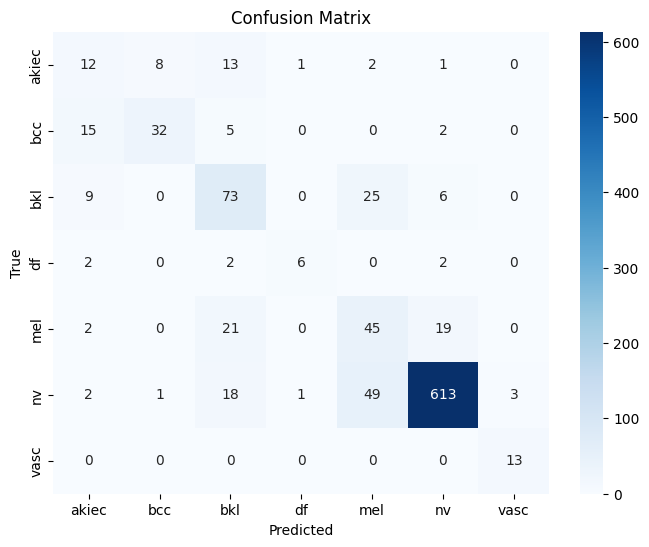

Saved confusion matrix to /content/confusion_matrix.png


<Figure size 640x480 with 0 Axes>

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

val_acc, val_f1, val_preds, val_probs, val_targets = evaluate_loader(val_loader, model_eval)
print("Val accuracy:", val_acc)
print("Val weighted F1:", val_f1)
print("\nClassification report:")
print(classification_report(val_targets, val_preds, target_names=classes))

cm = confusion_matrix(val_targets, val_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix')
plt.show()

# Save the confusion matrix image
plt.savefig('/content/confusion_matrix.png', bbox_inches='tight')
print("Saved confusion matrix to /content/confusion_matrix.png")


In [ ]:
tta_transforms = [
    val_transform,
    transforms.Compose([transforms.Resize((IMAGE_SIZE,IMAGE_SIZE)), transforms.RandomHorizontalFlip(p=1.0), transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
    transforms.Compose([transforms.Resize((IMAGE_SIZE,IMAGE_SIZE)), transforms.RandomVerticalFlip(p=1.0), transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
]

def tta_predict(img_path, T=1.4):
    img = Image.open(img_path).convert('RGB')
    probs = []
    with torch.no_grad():
        for t in tta_transforms:
            x = t(img).unsqueeze(0).to(DEVICE)
            logits = model_eval(x)
            logits = logits / T
            p = torch.softmax(logits, dim=1)[0].cpu().numpy()
            probs.append(p)
    avg = np.mean(probs, axis=0)
    pred_idx = int(np.argmax(avg))
    return classes[pred_idx], float(avg[pred_idx]), avg

# Usage:
# pred, conf, all_probs = tta_predict('skin disease.jpg')
# print(pred, conf)


In [ ]:
from google.colab import drive
import shutil, json
drive.mount('/content/drive')

# copy model
shutil.copy('/content/best_quantum_skin.pth', '/content/drive/MyDrive/best_quantum_skin.pth')

# save class_info
with open('/content/class_info.json','w') as f:
    json.dump(class_info, f, indent=2)
shutil.copy('/content/class_info.json', '/content/drive/MyDrive/class_info.json')

# copy confusion matrix if exists
if os.path.exists('/content/confusion_matrix.png'):
    shutil.copy('/content/confusion_matrix.png', '/content/drive/MyDrive/confusion_matrix.png')

print("Saved model, class_info and confusion matrix to Google Drive (MyDrive).")


Mounted at /content/drive
Saved model, class_info and confusion matrix to Google Drive (MyDrive).
